# The CAPM and Market Model Regressions

This notebook covers several related topics. The first topic is the "capital asset pricing model" or (CAPM). You should have seen this in (at least) FIN 3134 and Investments, so this should be a review. In addition to a quick review of the model, we focus on the key testable implications of the model. 

We then review the "market model." This model relates the return on an asset to the market return, allowing for an additional asset-specific or *idiosyncratic* component. This is a *single factor* model, where the market return serves as the factor. 

Next we discuss how to estimate the market model, and the most common types of statistical tests for the model. This entails an important review of the properties of **linear regression**, in this case of the "bivariate" type.

Concepts will be illustrated by using returns data from Ken French's data library. We will focus on a set of 25 portfolio returns that are formed by sorting individual stocks according to size (market capitalization) and book-market ratio. These portfolios served as some of the early compelling evidence against the CAPM, i.e., illustrating the key model implication does not appear to be satisfied in the data. 

*Acknowledgment*: This notebook was produced with the assistance of AI. I remain responsible for the content and any errors. 


## Learning Objectives

By the end of this notebook, you should be able to:

1. State the CAPM's key assumptions and derive its central implication, the beta-pricing relation $E(R_i) - R_f = \beta_i (E(R_m) - R_f)$.
2. Explain how the market model, $R_{i,t} - R_{f,t} = \alpha_i + \beta_i (R_{m,t} - R_{f,t}) + \epsilon_{i,t}$, embeds the CAPM as a testable hypothesis: $\alpha_i = 0$.
3. State the OLS estimators for the intercept and slope of a bivariate regression, and the assumptions needed for them to be unbiased, consistent, and asymptotically normal.
4. Compute standard errors, $t$-statistics, and $p$-values for OLS estimates, and use them to test $H_0: \alpha_i = 0$ for an individual asset.
5. Estimate a market model regression in Python two ways -- from closed-form OLS formulas, and via the `statsmodels` package -- and confirm the two approaches agree.
6. Apply market model regressions to the 25 Fama-French size- and book-market-sorted portfolios, and interpret the resulting alpha and beta estimates both economically and statistically.
7. Explain why the pattern of estimated alphas across the 25 portfolios constitutes evidence against the CAPM, and connect this to the historical Fama-French research that motivates multifactor models.
8. (Optional, appendix) Describe at a conceptual level how the GRS test combines information across multiple market model regressions to test whether all 25 alphas are jointly zero.


## Instructions to Run

**Data:** This notebook pulls data directly from Kenneth French's Data Library at runtime, via `pandas_datareader` -- there is no local CSV to download. It fetches two datasets: the "25 Portfolios 5x5" size- and book-market-sorted portfolio returns, and the "F-F Research Data Factors" file (market excess return and risk-free rate). **An internet connection is required to run this notebook.** If the data pull is slow or fails, French's site is occasionally unreachable or rate-limits requests -- wait a moment and re-run the cell.

**Package dependencies:** `numpy`, `pandas`, `matplotlib`, `scipy`, `statsmodels`, and `pandas_datareader` -- all but the last are standard scientific-Python packages included in a typical Anaconda install. Otherwise: `pip install pandas numpy matplotlib scipy statsmodels pandas_datareader`.


## Motivating data: size- and book-market-sorted portfolio returns

To motivate the topic and give things a practical context, let's introduce some data. The data consist of a relatively long history of monthly returns on a set of 25 stock portfolios. The data come from Ken French's data library. 

For some context, you can think of the portfolios as approximating various different types of "investment styles". For example, some investors might subscripe to a "value investing" perspective, and choose to hold a set of stocks that lean toward stocks with high book-market ratios (intuitively these are "value" because you are getting more assets for the money). 

Similarly, some investors prefer to hold relatively small cap stocks, whereas others prefer large cap stocks. The 'Fama-French 25 ME and BM-sorted portfolios' are just that: a set of portfolios that are formed by sorting individual stocks into 25 buckets based on their relatively size (market capitalization) and book-market ratios. 

The portfolios are "re-balanced" each year in June based on size and book-market as of the previous year. This is to be sure all accounting data would be available to investors so that the portfolios are feasible options.

The Python code below reads in the portfolio returns data.  We will also need data for market (excess) returns and risk-free returns. These are provided by a different file in the French data library. 

In [3]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import datetime as dt
import matplotlib.pyplot as plt
from pandas_datareader.famafrench import get_available_datasets
import warnings
#This bit will avoid us being inundated with warnings about the 'data parser' functionality in datareader
warnings.filterwarnings('ignore')

#Note: we will get our returns data from Ken French's website

#We will look at around 60 years of past monthly data for the sorted portfolios
start = dt.datetime(1964, 1, 1)
end = dt.datetime(2024, 12, 31)

frenchsets = get_available_datasets()
#print(frenchsets)

#Here we pull the data from French's website
ffsizebm = web.DataReader('25_Portfolios_5x5', 'famafrench',start,end)
#Print a description of the data
print(ffsizebm['DESCR'])

#We will use monthly value-weighted returns (object 0)
ffret = ffsizebm[0]

ffret.tail(5)


25 Portfolios 5x5
-----------------

This file was created using the 202506 CRSP database. It contains value- and equal-weighted returns for portfolios formed on ME and BEME. The portfolios are constructed at the end of June. BEME is book value at the last fiscal year end of the prior calendar year divided by ME at the end of December of the prior year. Annual returns are from January to December. Missing data are indicated by -99.99 or -999. The break points include utilities and include financials. The portfolios include utilities and include financials. Copyright 2025 Eugene F. Fama and Kenneth R. French

  0 : Average Value Weighted Returns -- Monthly (732 rows x 25 cols)
  1 : Average Equal Weighted Returns -- Monthly (732 rows x 25 cols)
  2 : Average Value Weighted Returns -- Annual (61 rows x 25 cols)
  3 : Average Equal Weighted Returns -- Annual (61 rows x 25 cols)
  4 : Number of Firms in Portfolios (732 rows x 25 cols)
  5 : Average Market Cap (732 rows x 25 cols)
  6 : For

,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,SMALL HiBM,ME2 BM1,ME2 BM2,ME2 BM3,ME2 BM4,ME2 BM5,...,ME4 BM1,ME4 BM2,ME4 BM3,ME4 BM4,ME4 BM5,BIG LoBM,ME5 BM2,ME5 BM3,ME5 BM4,BIG HiBM
Date,,,,,,,,,,,,,,,,,,,,,
2024-08,-1.6950,-4.2770,-2.6546,-3.7695,-2.1264,0.5129,0.2862,-3.5651,-2.2203,-1.8098,...,1.7784,2.0276,1.6154,1.4800,-0.4794,2.1542,3.8851,-0.6439,4.1499,0.9392
2024-09,1.6419,1.0592,-1.5476,-1.2206,-0.2320,0.5382,1.3042,0.9173,-0.5248,-0.8892,...,3.4515,2.2293,1.2623,3.6538,-1.3147,2.4193,3.9932,1.0625,-1.1408,-0.5286
2024-10,5.3571,0.4751,-0.7511,-0.9102,0.6604,-0.9067,-0.9828,-3.1869,-0.4686,-1.1391,...,-1.0064,-1.8012,-1.6277,1.5997,1.5252,-0.7923,-1.3078,-1.0778,0.3623,5.8880
2024-11,10.6097,10.0156,9.5950,8.9858,10.7434,14.3043,13.5425,10.8019,12.6711,10.4051,...,9.7341,6.8908,5.7647,10.4277,12.7063,6.3182,5.3370,5.1811,8.9070,11.3097
2024-12,-5.5404,-4.9960,-6.7628,-7.7747,-4.5746,-4.3803,-9.1695,-8.8408,-8.8516,-6.8635,...,-8.2650,-7.1663,-6.4893,-6.2309,-5.5524,0.3266,-4.8243,-8.9540,-6.7956,-5.7414


In [5]:
#We also need data for the risk-free rate and the market, which we can get from:
fffactors = web.DataReader('F-F_Research_Data_Factors', 'famafrench',start,end)

print(fffactors['DESCR'])

ffmfactors = fffactors[0]

ffmfactors.tail(5)


F-F Research Data Factors
-------------------------

This file was created using the 202506 CRSP database. The 1-month TBill rate data until 202405 are from Ibbotson Associates. Starting from 202406, the 1-month TBill rate is from ICE BofA US 1-Month Treasury Bill Index. Copyright 2025 Eugene F. Fama and Kenneth R. French

  0 : (732 rows x 4 cols)
  1 : Annual Factors: January-December (61 rows x 4 cols)


,Mkt-RF,SMB,HML,RF
Date,,,,
2024-08,1.60,-3.49,-1.10,0.48
2024-09,1.72,-0.13,-2.77,0.40
2024-10,-1.00,-0.99,0.86,0.39
2024-11,6.49,4.46,0.15,0.40
2024-12,-3.17,-2.71,-3.00,0.37


## Excess returns for the sorted portfolios: descriptive statistics

Let us first look at some basic descriptive analysis of the size and book-market sorted portfolios. 

The Python code below plots estimates of the average excess return or *risk premium* for each of the 25 portfolios. Then the code creates a table of basic descriptive statistics similar to the one we produced in an earlier class.

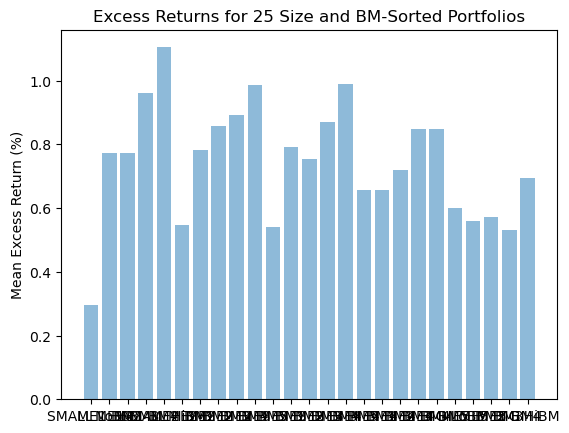

        SMALL LoBM     ME1 BM2     ME1 BM3     ME1 BM4  SMALL HiBM  \
min     -34.765200  -31.277800  -29.192900  -28.958300  -29.084300   
max      35.959400   43.086200   27.701300   27.685600   41.211300   
mean      0.296628    0.771048    0.772667    0.961154    1.104221   
median    0.569300    0.768900    0.910350    0.994900    1.063500   
std       8.004343    6.981094    6.119955    5.884362    6.327100   
skew     -0.053589    0.140211   -0.215202   -0.144255    0.120630   
kurt      1.737300    3.283272    2.021231    2.970520    4.756417   
count   732.000000  732.000000  732.000000  732.000000  732.000000   

           ME2 BM1     ME2 BM2     ME2 BM3     ME2 BM4     ME2 BM5  ...  \
min     -33.084800  -32.541200  -29.260100  -25.261600  -32.092800  ...   
max      30.239300   26.040500   26.035200   26.600700   29.074100  ...   
mean      0.547634    0.782162    0.856557    0.892481    0.987434  ...   
median    0.812900    1.193700    1.151800    1.350900    1.333700  .

In [8]:
#Here we use the df.sub() method to subtract the risk-free rate from all the returns. The axis="index" bit is important.
ffexret = ffret.sub(ffmfactors['RF'],axis="index")
ffexret.tail(5)

mean_exret = ffexret.mean()
#print("Asset means:")
#print(mean_exret)

y_pos = np.arange(len(mean_exret.index))

plt.bar(y_pos, mean_exret, align='center', alpha=0.5)
plt.xticks(y_pos, mean_exret.index)
plt.ylabel('Mean Excess Return (%)')
plt.title('Excess Returns for 25 Size and BM-Sorted Portfolios')

plt.show()

summarydf = ffexret.agg(['min','max','mean','median','std','skew','kurt','count'])
summarydf.style.format('{0:,.3f}').set_caption("Summary Statistics for FF Monthly Size and BM-Sorted Portfolios, 1964-2022.")
print(summarydf)


### What do the descriptive statistics tell us?

The figure and descriptive statistics indicate that there are (economically) significant differences in average excess returns across the size- and book-market-sorted portfolios. 

To provide some perspective, the mean excess return on the "small growth" portfolio (top left of table) is about 0.3\% per month, or about 3.2\% per year. In contrast, the mean excess return on several of the "value" portfolios (HiBM) are around 0.8-1\% per *month*, or about 10-12\% per year. This is a big difference.

But there are two key questions:

1. Are these differences in average excess returns *statistically* significant? 
2. What is the economic explanation for differences in average excess returns? Presumably they reflect differences in risk, but what is the relevant risk?

We can answer the first question by conducting a statistical test for the difference in means between two series. 

In order to answer the second question, we need a theoretical foundation. The natural starting point is the capital asset pricing model, or CAPM. It is worth reviewing this...



## The CAPM

### History and importance
The capital asset pricing model (CAPM) was proposed in a series of related, roughly contemporaneous papers by Jack Treynor (1961), William Sharpe (1964), John Lintner (1965), and Jan Mossin (1966), building on the ideas of mean-variance optimization (our previous topic) pioneered by Harry Markowitz (1952). (*Note: Markowitz, who won the Nobel prize in economics, recently passed away.*) 

The importance of the CAPM in financial economics is difficult to overstate. It was the first clear theory emphasizing that the relevant risk in holding a financial asset is **not** the variation in that asset's price in isolation, i.e., the volatility of the asset's return, but is rather driven by the extent of the **co-movement (beta)** of that asset with respect to the market portfolio.

### Rough intuition

The basic intuition behind the key insight above comes fundamentally from mean-variance theory and diversification. Consider the risk of holding common stock in McDonalds. It might seem reasonable to think that the variance of MCD measures is the measure of risk that investors should require compensation to hold. However, this rationale implicitly assumes that an investor is *only* holding MCD, i.e., that the investor has made a 100\% allocation to MCD. But mean-variance theory suggests that this is simply not a rational/reasonable investment portfolio. Instead, all investors should hold *diversified* portfolios. This, in turn, suggests that the right risk measure for MCD should capture to what extent adding a little bit of MCD to an *already diversified portfolio* will increase the variance/volatility of the portfolio return. This leads us to the beta measure that is central to the CAPM. 

### Sketch of the theory

The theory is built on a set of strong assumptions, including the following:

1. Investors have only financial wealth
2. Investors choose mean-variance optimal portfolios in an environment with risky assets and a risk-free option
3. All investors perceive the same set of means, variances, and covariances for all available investments
4. There are no taxes, trading costs, or other frictions
5. Asset markets are in equilibrium

The first four assumptions, taken jointly, imply (from our earlier MV segment) that *all investors* will obey "two-fund separation": they will hold some combination of the tangency portfolio of risky assets (on the MV frontier) and the risk-free asset. 

**Key equilibrium argument**: So far, we have just re-capitulated ideas from MV optimal portfolios. To take the next step, we invoke the assumption that asset markets are in equilibrium. The critical implication here is that all securities must be held in equilibrium, i.e., *supply must equal demand for all securities*. This, in turn, implies that the **tangency portfolio must equal the market portfolio**, where the market portfolio formally means the value-weighted portfolio of all (risky) assets.

**Bottom line**: The CAPM boils down to a set of assumptions delivering the implication that the market portfolio is MV efficient (and is in fact the tangency portfolio).

As the section below illustrates, the implication that the market portfolio is the tangency portfolio is very important and implicitly determines the correct measure of risk under the model.


### Key implications of CAPM
As noted above, a key implication is that the (value-weighted) market portfolio is MV efficient. It turns out that this implies (in fact is equivalent) to a very important "beta pricing relation". This relates the average return or risk premium (when we subtract the risk-free rate from the average return) for any asset to the "beta" of that asset, which measures the extent to which the asset's return co-moves with market excess returns.

In order to state the relation in a precise way, we need some notation:

$R_{i}$ is the return on the stock (asset) $i$, $R_{m}$ is the return on the market

$R_{f}$ is the risk-free rate

Beta: $\beta_{i} \equiv \frac{\text{Cov}(R_{i},R_{m})}{\text{Var}(R_{m})} = \frac{\rho(R_{i},R_{m}) \sigma_{R_{i}}}{\sigma(R_{m})}$

With this notation, the key "beta-pricing" relation implied by the CAPM is given by the following equation:
$E(R_{i}) - R_{f} = \beta_{i} (E(R_{m} - R_{f}))$

or, equivalently:

$E(R_{i}) = R_{f} + \beta_{i}  (E(R_{m} - R_{f}))$

The key CAPM equation in words:

"The risk premium for stock $i$ equals the stock $i$'s market beta times the market risk premium"

What makes the CAPM (and the relation described above) powerful is that, given the market risk premium, the model implies that the *only* thing driving variation in risk premiums across different stocks or other portfolios/assets is variation in market betas. 

Put another way, the CAPM implies that *any two stocks/assets with the same market beta must have the same risk premium and average return*.

The CAPM is an example of a *factor model*. In general, factor models posit that a set of underlying risk sources are "priced": investors demand compensation in equilibrium in the form of a risk premium for exposure to the relevant factor risks. 

The CAPM is a *single factor model*: the model implies that there is only one source of priced risk, which is exposure to fluctuations in the market excess return. The market risk premium is the compensation that investors require to bear risk in this single factor model. Next week we will discuss *multi-factor models* that extend the CAPM by incorporating additional factors.


## Testing the CAPM Empirically: Market Model Regressions

The CAPM is a *theory*. Its implication hold by logic *under the maintained assumptions*. But the maintained assumptions are very strong and arguably unrealistic in many ways. For example, it is highly unlikely that all investors agree about expected returns across all investment options, let alone regarding correlations, etc. Transactions costs and taxes are relevant in practice. Not all wealth is financial (labor income matters for most individuals). And so on...

It is therefore important to test whether the key implications of the CAPM hold in the data. 

In order to test the model, we need to embed it into a more general setting. A natural way to do this is to consider the market (single-factor) model for returns:

$R_{i,t} - R_{f,t} = \alpha_{i} + \beta_{i} (R_{m,t} - R_{f,t}) + \epsilon_{i,t}$

$R_{i,t} - R_{f,t}$ is the excess return for stock $i$ in period $t$ (e.g., month). $R_{m,t} - R_{f,t}$ is the market excess return in period $t$. The model assumes that there is a relation between the two, captured by $\beta_{i}$, which has the same interpretation as in the CAPM. 

*Note:* Here the risk-free rate has a time subscript. This is because in practice the risk free rate changes over time. What makes it "risk-free" despite this is that the return $R_{f,t}$ that can be earned for the risk-free asset is *known with certainty* at the beginning of the period.

$\epsilon_{i,t}$ is the *idiosyncratic* return shock for stock $i$ in a given period. By this we mean that this part of the return is unrelated to the systematic (market) return. It is a "firm-specific" shock each period. Formally, we assume that the idiosyncratic shock is mean zero and uncorrelated with market excess returns (and idiosyncratic shocks to other assets).

In order to see how this model can be used to test the CAPM, take the average (over time) of each side of the model equation. This gives:
$E(R_{i} - R_{f}) = \alpha_{i} + \beta_{i} E(R_{m} - R_{f}) $.

This looks *almost* like the key CAPM equation above, except there is something extra: the $\alpha_{i}$ term. This can be interpreted as an 'extra' component of the stock $i$ risk premium that is not related to market risk exposure. If $\alpha_{i}$ is positive, the stocks seems like a "good deal" (higher risk premium than market risk exposure warrants). If negative, the stock seems like a "bad deal." 

The key point is that the CAPM implies that $\alpha_{i} = 0$ for all stocks/assets. This is a **testable hypothesis**. 

We can collect data in the form of historical excess returns on one or more stocks or portfolios, as well as for the market. Then we can run a **bi-variate linear regression** of stock excess returns as ("Y") on market excess returns ("X"). This will give us *estimates* of $\alpha_{i}$ and $\beta_{i}$. 

We can then conduct a formal statistical test of the null hypothesis that $\alpha_{i} = 0$. If we reject this null hypothesis, we are rejecting the CAPM, i.e., concluding that the data do not support the key implications of the model.

Since we ultimately want to do inference in the context of a linear regression, it is worth reviewing the key statistical results.



## Linear regression review (bivariate case)

Suppose we have data on two variables $y$ and $x$, i.e., we have a sample of size $T$: $(x_{1},y_{1}),(x_{2},y_{2}),...(x_{T},y_{T})$. Note: I am using $T$ rather than $N$ here because in market model regression that data are observations over time. 

### The linear regression model

The Python code below plots excess returns for the first of the sorted portfolios (SMALL LoBM) against market excess returns. It is visually clear that a positive relation exists between these outcomes. At the same time, the plot is "noisy" and there certainly is not a simple deterministic relation between the outcomes. 

In linear regression, we posit an (imperfect) linear relationship between $y$ and $x$, called the **linear regression model**: $y_{t} = \alpha + \beta x_{t} + \epsilon_{t}$, where

1. The index $t$ runs from $1,...,T$
2. $y_{t}$ is called the *dependent variable*, *regressand*, or *left-hand variable* (all synonyms)
3. $x_{t}$ is called the *independent variable*, *explanatory variable*, *regressor*, or *right-hand variable* (again all synonyms)
4. $\alpha + \beta x_{t}$ is called the *population regression line*
5. $\alpha$ is the *intercept* of the population regression line
6. $\beta$ is the *slope* of the population regression line
7. $\epsilon_{t}$ is the *regression error term* or simply *error term*, or *residual*

In short, the model posits a linear relation between $y_{t}$ and $x_{t}$, but allows for this relation to be "imperfect" due to the (random) error term $\epsilon_{t}$. 


### Linear regression as prediction

We can think of the linear regression model as a model for predicting a new value of $y_{t}$ given the value of $x_{t}$. In general, $y_{t}$ could be an arbitrary function of $x_{t}$, e.g., $y_{t} = 4 + 3 x_{t} - 2 x_{t}^{2} + 0.25 x_{t}^{3} + \epsilon_{t}$, or more generally $y_{t} = f(x_{t}) + \epsilon_{t}$ where $f(\cdot)$ is an unspecified function. We generally assume that the $\epsilon_{t}$ error component is unpreditable (we will make a formal assumption to this effect below). In that case, the best forecast for $y_{t}$ given $x_{t}$ is $f(x_{t})$. But, in general we do not know what is the correct prediction function $f(x_{t})$. 

It might seem that the best thing to do would be to allow for a potentially complicated and nonlinear function and "see what the data say". But, it turns out that this approach is prone to "overfitting," in which we fit a set of training data very well, but the prediction model performs poorly in predicting new data. We will discuss this problem in more detail later in the course.

Linear regression helps address the overfitting problem by committing to a relatively simple (linear) functional relationship between $y_{t}$ and $x_{t}$. 

### Interpretation of the parameters and causality

How can we interpret $\alpha$ and $\beta$ in the linear regression model? 

$\beta$ is the *slope parameter*. It can be interpreted as capturing the change in our predicted value of $y_{t}$  given a one unit increase in $x_{t}$. Applying this concept to our CAPM regression, $\beta$ describes how much we would increase our prediction of the excess return $y_{t}$ given a one unit increase in the market excess return ($x_{t}$). If we measure excess returns in percentage terms, and if $\beta = 2$ for a given stock, then for each 1\% increase the market excess return, we predict that the excess return on the stock will be 2\% higher. 

$\alpha$ is the *intercept* parameter. It can be interpreted as our best prediction of $y_{t}$ when $x_{t} = 0$. In the CAPM context, we can interpret the intercept as the best prediction for the excess return on a stock if the market excess return equals zero. Of course, financial theory provides another equivalent interpretation: because the best prediction is the (conditional) average, the intercept equals the average excess return given that the market excess return equals zero. The economic theory of the CAPM predicts that this should equal zero for any stock. 

In general we should be very careful about giving a *causal* interpretation to a regression model parameter such as $\beta$. Here it is useful to remember the old adage: *correlation does not imply causation*. The regression slope $\beta$ reflects the degree of covariation/correlation. *This does not necessarily imply that $\beta$ can be interpreted as a **causal** impact of $x$ on $y$.* In this course, we will primarily focus on linear regression as a prediction method. In this case, we are only interested in useful prediction and not on establishing causal effects.

### Estimating the model parameters

The linear regression model has two key parameters $\alpha$ and $\beta$. We can use our $T$ sample observations $(y_{t},x_{t})$ to estimate these parameters. 

But how, precisely, should we do this?

The most common approach called *ordinary least squares (OLS)* chooses the parameters $\alpha$ and $\beta$ to minimize the sum of squared errors (hence "least squares") over sample observations. 

Mathematically, we solve the problem:

$\min_{\hat{\alpha},\hat{\beta}} \sum_{t=1}^{T} \hat{\epsilon}_{t}^{2} = \sum_{t=1}^{T} (y_{t} - \hat{\alpha} + \hat{\beta} x_{t})^{2}$

This problem is relatively easy to solve (the solution is given later). The Python code below illustrates the best fit line or the *estimated regression line* to the data for first of the 25 sorted portfolios (SMALL LoBM). Here the estimates of $\alpha$ and $\beta$ are produced by NumPy's "polyfit" function (fit a polynomial) specifying a first-order polynomial (linear). But there are other Python methods for doing OLS that offer additional, useful output.

Quick insigts:

1. The estimated regression line clearly slopes upward. This means that the OLS estimate of $\beta$ for this regression is positive.
2. Although the regression line is not plotted all the way to the y-axis, it is visually clear that the intercept is negative. This means that our estimate of $\alpha$ in this regression is negative.

**Important** It is crucial to understand that these are just *estimates* of the true parameters $\alpha$ and $\beta$, which are unknown. If we conduct a similar linear regression with a different sample of data (even drawn from the same true joint distribution) we will obtain different estimates. This is why it is important to be able to conduct *statistical inference* about linear regression parameter estimates. We will discuss this below.




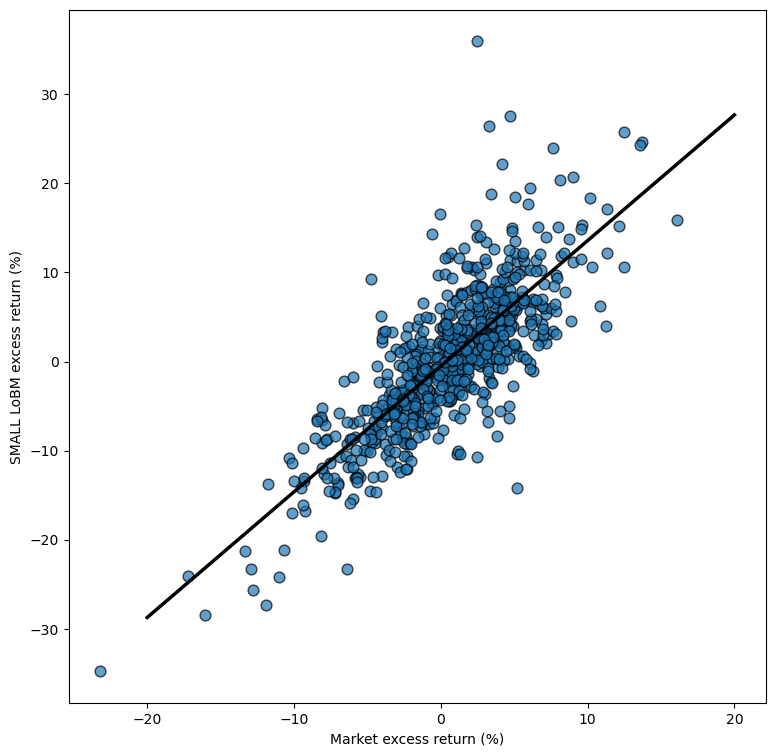

In [12]:
# Initialize layout
fig, ax = plt.subplots(figsize = (9, 9))

ploty = ffexret.iloc[:,0]
plotx = ffmfactors.iloc[:,0]
# Add scatterplot
ax.scatter(plotx, ploty, s=60, alpha=0.7, edgecolors="k")

plt.ylabel("SMALL LoBM excess return (%)")
plt.xlabel("Market excess return (%)")

# Fit linear regression via least squares with numpy.polyfit
# It returns an slope (b) and intercept (a)
# deg=1 means linear fit (i.e. polynomial of degree 1)
b, a = np.polyfit(plotx, ploty, deg=1)

# Create sequence of 100 numbers from 0 to 100 
xseq = np.linspace(-20, 20, num=100)

# Plot regression line
ax.plot(xseq, a + b * xseq, color="k", lw=2.5);

### OLS properties

This section briefly covers the statistical properties of OLS estimates of the intercept and slope in a standard bi-variate regression model. Below, we will apply exactly this type of regression model to study the relationship between excess returns on the size- and book-market sorted portfolios and market excess returns. Our key interest will be in whether we can reject the "null hypothesis" that the intercept (alpha) in the regression is zero, which is implied by the CAPM.

In the bivariate regression model, the OLS estimates that minimize the above can be written as follows (a sketch of the derivation is at the very bottom):

$\hat{\beta}  = \frac{(1/T)\sum_{t=1}^{T}(y_{t} - \bar{y})(x_{t} - \bar{x}))} {(1/T)\sum_{t=1}^{T}(x_{t} - \bar{x})^{2}} = \frac{\hat{\sigma}_{x,y}}{\hat{\sigma}^{2}_{x}}$

$\hat{\alpha} = \bar{y} - \hat{\beta} \bar{x}$

The $\hat{\sigma}_{x,y}$ and $\hat{\sigma}^{2}_{x}$ in the beta equation are the *sample covariance* between $x$ and $y$ and the *sample variance* of $x$. 

In these equations, $\bar{y}$ means the sample average of $y$ and $\bar{x}$ means the sample average of $x$.

Notice the intuition for the form of $\hat{\beta}$: we plug-in the sample covariance of $x$ and $y$ in the numerator and the sample variance of $x$ in the denominator. (A subtlety is that there is no "degree of freedom" correction for either.) Then the intercept estimate $\hat{\alpha}$ is the difference between the sample average of $y$ and the sample average of $x$ times our estimate of $\beta$.

An important regression diagnostic is the $R^{2}$-value. This is defined as:

$R^{2} \equiv \frac{\sum_{t=1}^{T} (y_{t} - \bar{y})^{2} - \sum_{t=1}^{T} \hat{\epsilon}_{t}^{2} } {\sum_{t=1}^{T} (y_{t} - \bar{y})^{2}} = \frac{\text{TSS}-\text{RSS}}{\text{TSS}},$ where TSS stands for "total sum of squares" and RSS stands for "residual sum of squares."


The OLS estimates are *random variables*. To understand this, imagine that we observe a different (new) sample of the data. We will get the same OLS estimates of $\alpha$ and $\beta$? *No.* They will differ, due to random variation in the data. 

What are the statistical/distributional properties of the OLS estimates? This depends in general on the particular assumptions we are willing to make. For example, introductory-level textbooks often invoke a set of very strong assumptions, such as:

1. The predictors $x_{1}, ..., x_{T}$ are "non-stochastic" or fixed (meaning, they do not change across different sample outcomes). 
2. The residuals $\epsilon_{1},...,\epsilon_{T}$ are independent draws from a normal distribution with mean zero and variance $\sigma^{2}_{\epsilon}$.

Under the above assumptions, the OLS estimates are unbiased and follow an exact bivariate normal distribution. But these results are of limited practical value, because the aforementioned assumptions are often unrealistic in finance and related applications.

Instead, we will make some weaker assumptions that are more realistic, and in the future we will discuss how the assumptions can be weakened even further (the fact that only limited assumptions are required is one reason regression is such a popular tool in data science!).

Assumptions (for now):

1. $(y_{t},x_{t})$ are independently and identically distributed (i.i.d.)
2. $E(y_{t} | x_{t}) = \alpha + \beta x_{t}$
3. $\text{Var}(\epsilon_{t} | x_{t}) = E(\epsilon_{t}^{2} | x_{t}) = \sigma^{2}_{\epsilon}$
4. Some technical "moment conditions" hold (e.g., $E(y) < \infty$, etc.)

Assumption 1 states the data are a "random sample" with observations drawn independently from the same distribution (does not have to be the normal distribution). In the future, we will talk about relaxing assumption 1 to permit the data to contain a 'cyclical' component over time. Assumption 2 involves a "conditional expectation". What it says in words is that, given a particular value of $x_{t}$, the average value of $y$ is $\alpha + \beta x_{t}$. Just below I'll talk about some other things that this assumption implies. Assumption 3 states that the variance of the residuals is constant for different realizations of $x_{t}$. This is actually restrictive and in general unlikely to be satisfied for real financial returns and related data. However, the assumption can be relaxed at the cost of more cumbersome standard error formulas so it is not particularly crucial. Assumption 4 rules out perverse cases in which averages are infinite, etc. 

Let's talk a bit more about the important Assumption 2. The assumption is equivalent to:

$E(\epsilon_{t} | x_{t} = 0)$

This means that, given $x_{t}$, the average value of the regression "error term" equals zero. 

What would be a violation of Assumption 2? Suppose that, in reality, $y_{t} = \alpha + \beta x_{t} + \delta x^{2}_{t} + \epsilon_{t}$, with $\delta \neq 0$. In this case $y_{t}$ is a *quadratic* function of $x_{t}$. Now, in this scenario, it should be intuitively clear that:

$E(y_{t} | x_{t}) = \alpha + \beta x_{t} + \delta x^{2}_{t}$, or equivalently

$E(\epsilon_{t} | x_{t}) = \delta x^{2}_{t} \neq 0$.

Intuitively, the true relationship between $y_{t}$ and $x_{t}$ is a *nonlinear* function of $x_{t}$. But our linear regression model excludes the nonlinear component, and hence the average error term is *not* zero given $x_{t}$. 

*Note*: We could fix this problem by just adding an additional regressor variable $z_{t} = x_{t}^{2}$. That would be a "multivariate regression," and we will cover this case soon.

There are two key additional implications of Assumption 2. They are:

1. $E(\epsilon_{t}) = 0$, i.e., the "unconditional" average of the error term is zero
2. $\text{Cov}(\epsilon_{t},x_{t}) = 0$, i.e., the regressor is *uncorrelated* with the error term

The second implication is important and necessary for the "nice properties" of the OLS estimator that are described immediately below.

With this background in place, and given our assumptions 1-4 above, "it can be shown that":

1. The OLS estimates are **unbiased**. Mathematically, $E(\hat{\beta}) = \beta$ and $E(\hat{\alpha}) = \alpha$ In words, unbiasedness means that the *average* realization of the sample estimates coincides with the true parameter values.
2. The OLS estimates are **consistent** for the true parameter values $\alpha$ and $\beta$. Mathematically, we can write this as $\hat{\beta} \rightarrow \beta$ as $T \rightarrow \infty$ and similarly for $\hat{\alpha}$. (Formally, the convergence is "in probability" because these are random variables.) In words, this property essentially means that, as the sample size $T$ becomes large, the estimates get arbitrarily close to the true parameter values. Again, speaking a bit loosely, this property means that if we have a large enough sample, we are effectively able to recover the true parameter value. Hopefully it is clear that this is a desirable property for an estimator.
3. The OLS estimates are **asymptotically normal**. This means that as the sample size increases, the distribution of the OLS estimates approaches (gets close to in a distributional sense) a (bi-variate) normal distribution. This property fundamentally comes from the **central limit theorem** from statistics.
4. The OLS estimates are **asymptotically efficient**. This property says that, among alternative consistent estimators, the OLS estimators have the smallest attainable variance in the limit (as $T$ increases). This is again a desirable property for an estimator.



## Statistical Inference for OLS Estimates in the Linear Regression Model

Above, it was stated that the OLS estimates in the linear regression model are approximately normally distributed in large samples. Furthermore, since the OLS estimates are unbiased, this distribution is centered around the true parameter values. These are nice results, but, to perform statistical inference, we need to know more. In particular, we need to be able to characterize, at least approximately, the *variance* of the large sample distribution. 

To understand better what we are after here, remember that for the sample mean we showed that (assuming i.i.d. data): $\text{Var}({\bar{x}}) = \frac{\sigma^2}{T}.$ We would like similar types of expressions for the variance of our OLS estimates.

The following gives the "asymptotic" (or approximate large sample) distributions for the OLS estimators $\hat{\alpha}$ and $\hat{\beta}$:

$\sqrt{T} (\hat{\beta} - \beta) \rightarrow N(0,\frac{\sigma^{2}_{\epsilon}}{\sigma^{2}_{x}})$

$\sqrt{T} (\hat{\alpha} - \alpha) \rightarrow N(0,\frac{\sigma^{2}_{\epsilon}(\sigma^{2}_{x} + \mu^{2}_{x})}{\sigma^{2}_{x}})$


Let's unpack these mathematical statements, using the $\beta$ case as an example. The result says that the difference between the OLS estimate of beta and the true beta, scaled by the square root of the sample size, is (approximately in large samples) normally distributed with a variance that equals the ratio of the variance of the error term relative to the variance of the predictor. We can re-write the limiting result for $\hat{\beta}$ in a way that helps emphasize what happens as the sample size $T$ gets large:

$(\hat{\beta} - \beta) \rightarrow N(0,\frac{\sigma^{2}_{\epsilon}}{T \sigma^{2}_{x}})$

All we have done here is use the fact that $\text{Var}(cX) = c^2\text{Var}(X)$, where $c$ is any constant, but this manipulation shows that the difference between $\hat{\beta}$ and the true parameter $\beta$ is approximately normally distributed with a variance that shrinks toward zero as the sample size $T$ becomes large. Intuitively, although there always remains randomness associated with the estimate $\hat{\beta}$, this randomness becomes increasingly concentrated around the true parameter value. This reflects the "consistency" property discussed above.

The interpretation of the intercept $\alpha$ result is similar, but with a slightly more complicated variance term. 

The above results let us do formal statistical inference regarding our estimates of the intercept and slope. But there is an issue: the variances depend on parameters like $\sigma^{2}_{\epsilon}$ that we do not know in practice. 

The resolution is to use the "plug-in principle" again: plug-in the obvious sample analogs to these parameters and use these for actual inference.
Define $\hat{\sigma}^{2}_{\epsilon} = (1/(T-2))\sum_{t=1}^{T} \hat{\epsilon}^{2}_{t}$ (sample variance of the residuals, where we adjust for two degrees of freedom related to the intercept and slope parameters). Also define $\hat{\sigma}^{2}_{x} = (1/T)\sum_{t=1}^{T} (x_{t} - \bar{x})^2$.

Plugging these into the formula for the asymptotic variance for $\hat{\beta}$ above and doing some (tedious) re-arraning, we get the following formula for the estimated variance of the slope estimate:

$\widehat{\text{Var}}(\hat{\beta}) = \frac{\hat{\sigma}^{2}_{\epsilon} T}{T \sum x^{2} - (\sum x)^2}$

Similarly, the formula for the (estimated) variance for the intercept parameter is:

$\widehat{\text{Var}}(\hat{\alpha}) = \frac{\hat{\sigma}^{2}_{\epsilon} \sum x^{2}}{T \sum x^{2} - (\sum x)^2}$


With these estimates in hand, we can conduct the typical sorts of *statistical inference* exercises done for linear regressions. For example, suppose we want to give a 95% confidence interval for the parameter $\alpha$. We can do this as follows:

95% interval = $[\hat{\alpha} - 1.96 \times \hat{\sigma}(\hat{\alpha}), \hat{\alpha} + 1.96 \times \hat{\sigma}(\hat{\alpha})]$, where $\hat{\sigma}(\hat{\alpha})$ is the standard deviation of the estimate (square root of the estimated variance given previously).

We can also conduct a "$t$-test" of the null hypothesis that $\alpha = 0$ (or that $\beta = 0$). Taking the alpha case as an important example, the null and alternative hypotheses are:
$H_{0}: \alpha = 0$, $H_{1}: \alpha \neq 0$.

The test statistic is:

$t = \frac{\hat{\alpha}}{\hat{\sigma}(\hat{\alpha})}$

This statistic is approximately standard normal under the null hypothesis. Consequently, we can compare the realized value of the $t$-statistic above with the "critical values" of the standard normal distribution. If the statistic exceeeds the critial value (in absolute value for a "two-sided test") then we reject the null hypothesis. The critical value depends upon the "significance" of the test. The significant parameter (a percentage) reflects the likelihood of "Type 1 errors" that we are willing to abide: the probability that we will falsely reject the null when in fact it is true. 

*Note*: If the data are exactly normally distributed, then the appropriately computed $t$-statistic (with the degrees of freedom adjustment) follows an exact $t$-distribution in finite samples (hence the name of the statistic). However, in financial applications it is often unlikely that the data are exactly normally distributed, and for this reason we concentrate on the "large sample" or "asymptotic" properties of the OLS estimator.

Suppose we wish to test the null that $\alpha = 0$ using the $t$-statistic at the 5% level. Then we reject the null hypothesis (i.e., conclude that the evidence supports a nonzero alpha) if $|t| > 1.96$ where 1.96 is the appropriate critical value form the standard normal distribution given our 5% significance level. 

*Note*: a judicial example is helpful in understanding the test significance. The null hypothesis is that the accused is innocent. The alternative is that the accused is guilty. Suppose we have a test statistic that involves some level of randomness, e.g., the potential of random error in ascertaining biological evidence, etc. If we set the test significance level to 5%, then we wish to bound the probability that an innocent individual is deemed guilty based on the test at 5% (max). 

A good online resource regarding critical values and associated statistical concepts is [here](https://www.statisticshowto.com/probability-and-statistics/find-critical-values/).

## Market model regressions for the sorted portfolios

Now let us turn to the question of whether the CAPM can explain the variation we see in excess returns across the size- and book-market-sorted portfolios. 

We will focus on the market model regression:

$(R_{i,t} - R_{f,t}) = \alpha + \beta (R_{m,t}-R_{f,t}) + \epsilon_{i,t}$

This can be written in "textbook" fashion as:

$Y_{t} = \alpha + \beta X_{t} + \epsilon_{t}$, where $Y_{t}$ is the excess return for the portfolio in question and $X_{t}$ is the excess return for the market.

We can estimate the model parameters using OLS (see statistical review above). 

Below, I hand-code a bivariate regression function in Python. This is ultimately for clarity -- when you code a statistical method yourself then the way the estimation and inference is performed is necessarily clear. 

There are in fact lots of ways to do linear regression / OLS in Python. Most of these leverage certain Python modules. By coding our own OLS function, we are keeping the Python requirements to a minimum (basically just Numpy). At the same time, the hand-coded function below has certain weaknesses. It omits some common diagnostics, for example, and it does not have any kind of error-checking logic and so it is more likely to crash out in an error especially if used in some other context. 

I will show an alternative way to do the regression using a Python module, and we can confirm that both approaches produce the same slope and intercept estimates.





In [17]:
import scipy.stats as st
#we only use the above for computing the p-value associated with the t-statistics

#Code up a bivariate regression function by hand
def bv_reg(x,y):
    
    #First compute various parameters we need to implement BV reg formulas:
    temp = np.corrcoef([x,y])
    xycorr = temp[0,1]
    xstd = x.std()
    ystd = y.std()
    yvar = y.var()
    xmean = x.mean()
    ymean = y.mean()
    N = len(y)
    xsum = x.sum()
    x2sum = np.dot(x,x)
    xsum2 = xsum**2
    
    #Now implement formulas and return objects of interest
    beta = (xycorr*ystd)/xstd
    #Note: the above is equivalent to  cov(x,y)/var(x) (plug in def of cov(x,y) to show this)
    alpha = ymean - beta*xmean
    yhat = alpha + beta*x
    resid = y - yhat
    sig2hat = resid.var(ddof=2)
    tss = N*yvar
    rss = np.dot(resid,resid)
    R2 = 100*(1-rss/tss)
    #compute std errors of alpha, beta hats and then t-statistics and p-values
    denom = N*x2sum - xsum2
    varalpha = (sig2hat*x2sum)/denom
    sealpha = np.sqrt(varalpha)
    talpha = alpha/sealpha
    palpha = 2 * st.norm.sf(abs(talpha))
    varbeta = (sig2hat*N)/denom
    sebeta = np.sqrt(varbeta)
    tbeta = beta/sebeta
    pbeta = 2 * st.norm.sf(abs(tbeta))
    #We will return a list of key statitsics and separately the residuals, which we will use later
    return [alpha, sealpha,talpha, palpha, beta, sebeta, tbeta, pbeta, R2], np.array(resid)

#Use/test the function
exmkt = ffmfactors.iloc[:,0]
yvar = ffexret.iloc[:,0]

stats, resids = bv_reg(exmkt,yvar)
print(stats)
#print(resids)



[-0.524782751841054, 0.18260149546426266, -2.8739236253613294, 0.00405406985975635, 1.4103789978130314, 0.04035891008684479, 34.94591392032542, 1.493854777088757e-267, 62.63855994981835]


In [19]:
#Now we apply the basic function in a loop structure to estimate the market model regression for each of the 25 portfolios.
# The statistics are stored in a convenient Pandas dataframe that we can then analyze.
# We will also store the residuals in an array (later changed to dataframe) so we can use them later

#We will use T and N later....
T = len(ffexret)
N = len(ffexret.columns) 

outdata = []
residmat = np.zeros((T,1))

for column in ffexret:
    yvar = ffexret[column]
    stats, resids = bv_reg(exmkt,yvar)
    outdata.append(stats)
    residmat = np.hstack((residmat,resids.reshape(T,1)))

df_resids = pd.DataFrame(residmat).iloc[: , 1:]
#print(df_resids)

outdf = pd.DataFrame(outdata)
outdf.columns = ['alpha', 'SE alpha','t-stat alpha','p-val alpha','beta','SE beta','t-stat beta','p-val beta','R-squared']
outdf.index = ffexret.columns
outdf


,alpha,SE alpha,t-stat alpha,p-val alpha,beta,SE beta,t-stat beta,p-val beta,R-squared
SMALL LoBM,-0.524783,0.182601,-2.873924,0.004054,1.410379,0.040359,34.945914,1.493855e-267,62.638560
ME1 BM2,0.058389,0.160641,0.363472,0.716253,1.223651,0.035505,34.463999,2.778619e-260,61.986903
ME1 BM3,0.123893,0.131540,0.941871,0.346259,1.113957,0.029073,38.315697,0.000000e+00,66.834759
ME1 BM4,0.354697,0.133267,2.661562,0.007778,1.041297,0.029455,35.352359,9.223144e-274,63.177762
SMALL HiBM,0.480981,0.153539,3.132620,0.001733,1.070115,0.033936,31.533731,2.996975e-218,57.723684
ME2 BM1,-0.255747,0.138563,-1.845711,0.064934,1.379422,0.030625,45.041679,0.000000e+00,73.574917
ME2 BM2,0.091651,0.113076,0.810528,0.417637,1.185621,0.024992,47.439600,0.000000e+00,75.541054
ME2 BM3,0.228652,0.104619,2.185575,0.028847,1.078126,0.023123,46.625732,0.000000e+00,74.896245
ME2 BM4,0.296651,0.107261,2.765706,0.005680,1.023051,0.023707,43.154072,0.000000e+00,71.877867
ME2 BM5,0.319340,0.133643,2.389498,0.016871,1.147131,0.029538,38.835741,0.000000e+00,67.429277


### Cross-check with another Python approach

Before diving into interpreting the results, let us quickly run the regression an alteranative way, specifically using the "statsmodels" module.

Note: Personally I recommend this module for running regressions in a research context, in particular I prefer it to the "sklearn" module, although that also works.

We will quickly run the excess return regression for the last portfolio BIG HiBM. The excess returns for this portfolio are currently in the 'yvar' variable based on our code above.

The output shows that we obtain the same alpha and beta estimates as using the hand-written code. The standard errors and t-statistics are nearly the same, likely differing by only a minor 'degree of freedom' correction.

You can see that the statsmodels version of OLS computes a lot of other statistics and diagnostics that one can access. I will not get into most of these today but will discuss some next week.


In [21]:
#cross check with the "stats models" module for Python (pre-canned regression functionality)
import statsmodels.api as sm

#print(exmkt)
#print(yvar)

#the next line adds a constant (vector of ones) to the regression 'design matrix'.
#It is important to remember that you need to do this assuming you want an intercept term as we usually do
regx = sm.add_constant(exmkt)
#Now we reun the regression and look at the results
regresults = sm.OLS(yvar,regx).fit()

regresults.summary()

#print(regresults.ssr)
#print(regresults.centered_tss)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               BIG HiBM   R-squared:                       0.616
Model:                            OLS   Adj. R-squared:                  0.615
Method:                 Least Squares   F-statistic:                     1169.
Date:                Tue, 16 Sep 2025   Prob (F-statistic):          9.74e-154
Time:                        13:44:09   Log-Likelihood:                -1954.9
No. Observations:                 732   AIC:                             3914.
Df Residuals:                     730   BIC:                             3923.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1185      0.130      0.908      0.364      -0.138       0.375
Mkt-RF         0.9863      0.029     34.197      0.000       0.930       1.043
==============================================================================
Omnibus:                       65.490   Durbin-Watson:                   1.959
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              338.914
Skew:                          -0.160   Prob(JB):                     2.55e-74
Kurtosis:                       6.318   Cond. No.                         4.57
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Interpreting the results
What do the tabulated market model regression results tell us?

Let's first focus on the beta estimates. Remember, the beta tells us about to what extent a given security's return co-move with market returns. All of the beta estimates are positive and range from 0.86-1.44 range.

Of course, these are just *estimates* of the true, unknown betas, but the standard errros (next column in the table) indicate that the estimates are quite precise. *Practice: what is a 95% confidence interval for the beta on the first portfolio?* 

The $t$-statistics are all much larger than 3 in absolute value -- this means that there is overwhelming evidence against the null that the true beta equals zero for all the portfolios. This is *not* surprising. *Can you explain why?*

Now, think about the CAPM: it says that *all* variation in excess returns should be explained (only) by variation in market betas. Given our estimates of market betas (taking them as truth momentarily) we would *expect* average excess returns on the portfolos to vary to some extent. For example, we would expect that the "Small LoBM" portfolio would have a *larger* average excess return (risk premium) than other portfolios because its beta is relatively high (1.4). But, in the data, it *doesn't*: it actually has a historical risk premium. This suggests that this portfolio has a negative alpha. So let's turn to the alpha estimates....

None of the alpha estimates are exactly zero as implied by the CAPM. This is *not* surprising and would be true even in a world in which the CAPM holds exactly. *Why? Be sure you can explain this.*

### Economic significance of estimated alphas
A number of the alpha estimates are "economically significant." Consider, for example, the alpha on the first portfolio SMALL LoBM. Per our intution above, the estimated alpha is negative (around -0.49). Remember that the data are monthly, so this translated to around a 6% per year *underperformance* relative to what CAPM predicts based on the high market beta estimate for this portfolio. In contrast, the portfolio SMALL HiBM, which consists of small value firms rather than small growth firms, earns a large *positive* alpha of around 0.54, translating to over 6% per year of outperformance. (The market beta for this portfolio is around 1, so CAPM says the risk premium should be the market risk premium, but in the data the risk premium estimate is 6% higher per year!)


### Statistical significance

The alpha estimates in the table for our 25 portfolios are often economically large, but remember that these are just estimates and therefore they are subject to sampling variation. Perhaps these large (in absolute value) alphas just occurred due to random chance. 

To address this issue, we turn to the standard errors for the alphas in the second column of the table, and the corresponding $t$-statistics in the third column. The standard errors are often somewhat large. For example the standard error for the first portfolio's alpha is around 0.18. This means that a 95% confidence interval for the alpha is wide, ranging from around -0.85 to -0.13. So it could be that the true alpha is significantly smaller in absolute value than our estimate of -0.49. But it also could be bigger in absolute value, and the confidence interval does not include zero. Thus, when we examine the $t$-statistic in column 3, we find that it is around -2.6, which is significantly larger in absolute value than the conventional cutoff of 2 (or 1.96 precisely), and thus we conclude that the null that $\alpha = 0$ should be rejected, and the data appear to vioate the predictions of CAPM for this portfolio.

Looking at other portfolios, results vary. In some cases alpha estimates are statistically insignnificant (we cannot reject the null). But, we do reject the null for around half of the 25 portfolios, which is quite strong evidence against the CAPM.

Comment: Our results should not a surprise for those who follow academic research (or paid close attention in Investments!). Two influential papers by Eugene Fama and Ken French established that portfolios sorted by market capitalization and book-market appear to violate the CAPM, and proposed an extension to the CAPM that adds two new "factors" to address this issue. We will discuss this "multifactor model" next week.


### Plotting the key results

The Python code below constructs a graph that conveys the key results regarding the estimated alphas. The graph plots the estimated alphas for the 25 portfolios, using differential color shading to indicate the degree of statistical significance (specifically the size of the $t$-statistic). The graph also shows the "security market line", which plots expected excess returns against market betas assuming that the CAPM holds exactly, and given our estimate of the market risk premium.

It is easy to see from the plot that the evidence against CAPM is quite strong for these portfolios. 



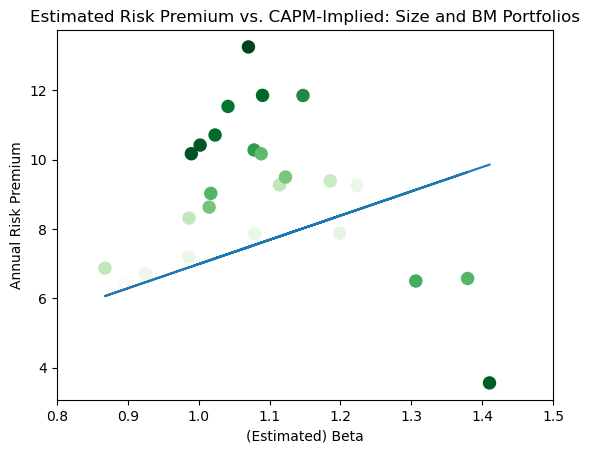

In [19]:
# Let's make a plot of key results
outdf["abst"] = abs(outdf["t-stat alpha"])
yvarplot = (outdf['alpha'] + outdf['beta']*exmkt.mean())*12
ycapm = outdf['beta']*exmkt.mean()*12
#Note the *12 at the end annualizes the model-based expected returns for interpretation
plt.scatter(outdf['beta'],yvarplot,s=75,c=outdf["abst"], cmap='Greens')
plt.plot(outdf['beta'],ycapm)
plt.xlim(0.8,1.5)
plt.xlabel("(Estimated) Beta")
plt.ylabel("Annual Risk Premium")
plt.title("Estimated Risk Premium vs. CAPM-Implied: Size and BM Portfolios")
plt.show()

## Takeaways

- Market betas for the 25 size- and book-market-sorted portfolios are all positive and estimated quite precisely, ranging from about 0.87 to 1.41.
- The CAPM predicts that beta alone should explain differences in risk premiums across portfolios (i.e., $\alpha_i = 0$ for every portfolio). In the data, roughly half of the 25 estimated alphas are statistically significant at the 5% level, and several are economically large -- on the order of several percentage points per year.
- This is a real, well-known empirical failure of the CAPM: portfolios formed by sorting on size and book-market have average returns that are not fully explained by their market betas.

**Why this matters.** This pattern is exactly what led Fama and French to propose adding size and book-market factors to the CAPM, producing the three-factor model. Next week's notebook takes up that multifactor extension directly, using the same market model regression machinery developed here -- just with more than one regressor on the right-hand side.


## Potential applications for capstone research projects

We have now reviewed the CAPM, market model regressions, and the statistical properties of bivariate linear regression. 

There are a number of potential applications of these ideas for capstone research projects. Among them:

1. Market model regressions are very common in the ongoing literature that investigates the validity of the CAPM and related multifactor model extensions. Suppose, for example, you conjectured that investors are subject to some particular behavioral or psychological bias that causes them to systematically overpay / underpay for certain types of stocks. One important test of this idea would involve forming portfolios based on stocks that are differentially exposed to this bias, and then running the same kind of market model regressions for these portfolios that we ran above for the size and book-market portfolios. (In fact, one possible explanation of the book-market-based alphas is that investors overvalue "glamour" stocks relative to "value" stocks.) 

2. It is also common to use market model regressions to measure the degree of "skill" possessed by professional investors in delegated investment settings (e.g., active mutual funds and hedge funds). 
3. The GRS statistic provides a sophisticated method for assessing whether the null that alphas are jointly zero can be rejected from some set of test assets or portfolios. This is again a common exercise in the context of assessing newly proposed factors, the extent to which fund managers (as a group) possess skill, etc.
3. More broadly, it is common to run bivariate linear regressions in many contexts in finance and related fields in order to statistically assess the relationship between two variables. Thus, many project topics might involve regressions of this sort, and it is important to execute the regressions carefully and (especially) to interpret the results carefully.


## Additional Technical Material

This appendix collects material beyond the core narrative above: a way of combining evidence across all 25 market model regressions into a single joint test, and the derivation of the OLS formulas used throughout. Both are optional.


### Putting together information from multiple market regressions (Optional)


**Warning: this part uses vector/matrix notation that goes beyond what we've covered in this course so far -- feel free to skip it.**

Let us briefly pursue one final extension. Thus far, we have focused on regression-based tests of the CAPM involving one particular asset (or portfolio) at a time. We did this for 25 different sorted portfolios. Recall that the results were mixed, with some portfolios giving us statistically significant alphas, and others such that the estimated alpha was not significantly different from zero.

Loosely, we concluded above that the fact that we reject the null for around half of the portfolios is strong evidence CAPM. But we can be more formal about this by combining information across the different market model regressions, i.e., across different "test portfolios." 

We will need some new notation, because we want to discuss the market model regressions *jointly* across $N$ securities or portfolios: 

$\hat{\alpha}$ is the $N \times 1$ *vector* of intercept estimates for the test portfolios. In the results table above, $\hat{\alpha}$ is the entire column of alpha estimates. 

$\mu_{m}$ will denote the market risk premium, and $\hat{\mu}_{m}$ is the estimate of this (sample average of market excess return).  $\hat{\sigma}^{2}_{m}$ is the sample variance of the market (excess) return.

$\Sigma_{\epsilon}$ is the $N \times N$ covariance matrix of residual return components. The diagonal of the matrix contains the variances of the residual returns for each of the 25 portfolios. The off-diagonal elements contain the co-variances, which we will not necessarily assume are zero. $\widehat{\Sigma}_{\epsilon}$ is the corresponding sample covariance matrix. 

We can compute $\widehat{\Sigma}_{\epsilon}$ as:

$\widehat{\Sigma}_{\epsilon} = \frac{1}{T} \sum_{t=1}^{T} \hat{\epsilon}_{t} \hat{\epsilon}_{t}^{\prime}$

(In terms of code, we can collect the residuals into a $T \times N$ matrix, and then ask Python to compute the $N \times N$ covariance matrix matrix.)

We are now ready to state an important result for testing the CAPM. Under the assumption that returns are (jointly) i.i.d. normally distributed, we have:

$F = \frac{T-N-1}{N} \left(1 + \frac{\hat{\mu}_{m}^{2}}{\hat{\sigma}^{2}_{m}}\right)^{-1} \hat{\alpha}^{\prime} \widehat{\Sigma}_{\epsilon}^{-1} \hat{\alpha} \sim F_{N,T-N-1}$

What does this statement even mean? It says that, under the null hypothesis that all $N$ of the alphas are zero, which would be consistent with the CAPM holding exactly, the GRS statistic on the left hand side of the $\sim$ follows an $F$ distribution with $N$ and $T-N-1$ degrees of freedom. This is a known distribution and we can ask Python to give us the critical values for a 5% (or other signficance level). This way, we can formally test whether the joint evidence from the market model regressions is consistent with CAPM.

This statistic and the corresponding test is often called the "GRS statistic" or "GRS test" in honor of a 1983 Journal of Finance paper by Gibbons, Ross, and Shanken that first provided a detailed analysis of the test in the context of testing factor models.

The $ \hat{\alpha}^{\prime} \widehat{\Sigma}_{\epsilon}^{-1} \hat{\alpha}$ part of the above statistic turns out to have an interesting economic interpretation: it equals the increase in the max squared Sharpe ratio that can be obtain from investing in the test portfolios as well as the market relative to just investing in the market. (Under the CAPM, this must be zero because the market gives the max possible Sharpe ratio.)


The Python code below makes a function capable of performing the GRS test and applies the test to our set of 25 portfolios. The "p-value" associated with the resulting testing statistic is tiny (like 0.0000000001). This means there is extremely strong evidence against the null hypothesis that the alphas are jointly zero. This is not terribly surprising given the many statistically significant alphas in the individual market model regressions, but the results emphasize how combining information across a set of "test portfolios" or assets can deliver much higher power relative to an individual market model regression.




In [21]:
#Let's do the GRS test for our set of 25 portfolios
# Below, I define a function that executes the test and returns the key test stat and p-value

# We will need the scipy module for this function
import scipy.stats

def grs_test(alphas,resids,exmkt):
    #Notes: resids and exmkt must accept .mean(), .cov() etc.
    N = len(alphas)
    T = len(exmkt)
    part1 = (T-N-1)/N
    mktmean = exmkt.mean()
    mktsd = exmkt.std()
    part2 = (1+(mktmean/mktsd)**2)**(-1)
    sige_inv = np.linalg.inv(resids.cov())
    qform = np.transpose(avec)@sige_inv@avec
    grs_stat = part1*part2*qform
    
    #Now do f distribution comparison (requires scipy)
    nun = N
    dun = T-N-1
    grs_pval = 1-scipy.stats.f.cdf(grs_stat, nun, dun)
    return grs_stat, grs_pval

#Get alphas for the test
avec = np.array(outdf['alpha'])

#Now run the test
grs_stat, grs_pval = grs_test(avec,df_resids,exmkt)


print("Test stat: ", grs_stat)
print("p-value: ", grs_pval)




Test stat:  4.1118380474815766
p-value:  1.6434154037625603e-10


### Derivation of OLS estimators

$\min_{\hat{\alpha},\hat{\beta}} =  \sum_{t=1}^{T} \hat{\epsilon}_{t}^{2} = \sum_{t=1}^{T} (y_{t} - \hat{\alpha} + \hat{\beta} x_{t})^{2}$

To solve this minimization problem, we will do the usual thing: take the derivatives (w/ respect to $\alpha$ and $\beta$) and set them to zero.

$\frac{\partial}{\partial \alpha}  \sum_{t=1}^{T} (y_{t} - \hat{\alpha} + \hat{\beta} x_{t})^{2} = -2 \sum_{t=1}^{T} (y_{t} - \hat{\alpha} + \hat{\beta} x_{t}) = 0 $

$\frac{\partial}{\partial \beta}  \sum_{t=1}^{T} (y_{t} - \hat{\alpha} + \hat{\beta} x_{t})^{2} = -2 \sum_{t=1}^{T} (y_{t} - \hat{\alpha} + \hat{\beta} x_{t}) x_{t} = 0$

Divide equal of these equations by $-2$ and then sum across observations and then divide by $T$ to get:

$\bar{y} - \hat{\alpha} - \hat{\beta} \bar{x} = 0 $

$(1/T)\sum y_{t} x_{t} - \hat{\alpha}\bar{x} - \hat{\beta} (1/T)\sum x_{t}^{2} = 0$ 

Solving these equations for $\hat{\alpha}$ and $\hat{\beta}$ gives:

$\hat{\beta} = \frac{(1/T)\sum y_{t}x_{t} - \bar{y}\bar{x}}{(1/T)\sum x_{t}^{2} - \bar{x}^2} = \frac{(1/T)\sum_{t=1}^{T}(y_{t} - \bar{y})(x_{t} - \bar{x}))} {(1/T)\sum_{t=1}^{T}(x_{t} - \bar{x})^{2}} $

$\hat{\alpha} = \bar{y} - \hat{\beta} \bar{x}$

